# Stage 06 — German Credit LIME Explanations

This notebook explains the frozen weighted model for the same 20 XAI cases used by SHAP. LIME uses the 800 training rows as background.


## 1. Frozen reconstruction


In [1]:
import json
from importlib.metadata import version
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score,
)

RANDOM_STATE = 42
NUM_SAMPLES = 5000
NUM_FEATURES = 5
DECISION_THRESHOLD = 0.50
RAW_TARGET = "class"
TARGET = "TARGET"

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "german_credit":
    candidate = NOTEBOOK_DIR / "backend" / "ml" / "german_credit"
    if candidate.exists():
        NOTEBOOK_DIR = candidate
    else:
        raise RuntimeError("Run from backend/ml/german_credit or the project root.")
BACKEND_DIR = NOTEBOOK_DIR.parents[1]
RAW_PATH = BACKEND_DIR / "data" / "german_credit" / "raw" / "german_credit_raw.csv"
ARTIFACTS_DIR = BACKEND_DIR / "artifacts" / "german_credit"
PLOTS_DIR = ARTIFACTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

required_paths = {
    "selection": ARTIFACTS_DIR / "selected_features.json",
    "display_mapping": ARTIFACTS_DIR / "feature_display_mapping.json",
    "category_mapping": ARTIFACTS_DIR / "category_value_mapping.json",
    "train_indices": ARTIFACTS_DIR / "train_indices.csv",
    "test_indices": ARTIFACTS_DIR / "test_indices.csv",
    "preprocessor": ARTIFACTS_DIR / "preprocessor.joblib",
    "preprocessing_metadata": ARTIFACTS_DIR / "preprocessing_metadata.json",
    "transformed_mapping": ARTIFACTS_DIR / "transformed_feature_mapping.csv",
    "model": ARTIFACTS_DIR / "xgboost_credit_model.joblib",
    "model_metadata": ARTIFACTS_DIR / "model_metadata.json",
    "xai_cases": ARTIFACTS_DIR / "xai_evaluation_cases.csv",
    "shap_top": ARTIFACTS_DIR / "shap_top_factors.csv",
    "shap_stability": ARTIFACTS_DIR / "shap_preliminary_stability.csv",
    "shap_faithfulness": ARTIFACTS_DIR / "shap_preliminary_faithfulness.csv",
}
assert all(path.exists() for path in required_paths.values())
print(f"LIME version: {version('lime')}")


LIME version: 0.2.0.1


In [2]:
raw_df = pd.read_csv(RAW_PATH)
selection = json.loads(required_paths["selection"].read_text(encoding="utf-8"))
display_mapping = json.loads(required_paths["display_mapping"].read_text(encoding="utf-8"))
category_mapping = json.loads(required_paths["category_mapping"].read_text(encoding="utf-8"))
preprocessing_metadata = json.loads(required_paths["preprocessing_metadata"].read_text(encoding="utf-8"))
model_metadata = json.loads(required_paths["model_metadata"].read_text(encoding="utf-8"))
train_indices = pd.read_csv(required_paths["train_indices"])["row_index"].astype(int)
test_indices = pd.read_csv(required_paths["test_indices"])["row_index"].astype(int)
transformed_mapping = pd.read_csv(required_paths["transformed_mapping"], keep_default_na=False)
xai_cases = pd.read_csv(required_paths["xai_cases"])
shap_top_factors = pd.read_csv(required_paths["shap_top"])
shap_stability = pd.read_csv(required_paths["shap_stability"])
shap_faithfulness = pd.read_csv(required_paths["shap_faithfulness"])
preprocessor = joblib.load(required_paths["preprocessor"])
model = joblib.load(required_paths["model"])

selected_features = selection["selected_features"]
numeric_features = selection["numeric_selected_features"]
categorical_features = selection["categorical_selected_features"]
y_all = raw_df[RAW_TARGET].map({1: 0, 2: 1}).rename(TARGET)
X_train_raw = raw_df.loc[train_indices, selected_features].copy()
X_test_raw = raw_df.loc[test_indices, selected_features].copy()
y_train = y_all.loc[train_indices].copy()
y_test = y_all.loc[test_indices].copy()
X_train_processed = preprocessor.transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

assert X_train_processed.shape == (800, 54)
assert X_test_processed.shape == (200, 54)
assert y_train.value_counts().to_dict() == {0: 560, 1: 240}
assert y_test.value_counts().to_dict() == {0: 140, 1: 60}
assert len(shap_top_factors) == 100 and len(shap_stability) == 5 and len(shap_faithfulness) == 5
print(f"Training rows reconstructed: {len(X_train_raw)}")
print(f"Test rows reconstructed: {len(X_test_raw)}")


Training rows reconstructed: 800
Test rows reconstructed: 200


## 2. Frozen performance and cases


In [3]:
test_probabilities = model.predict_proba(X_test_processed)[:, 1]
test_predictions = (test_probabilities >= DECISION_THRESHOLD).astype(int)
reproduced_metrics = {
    "roc_auc": roc_auc_score(y_test, test_probabilities),
    "pr_auc": average_precision_score(y_test, test_probabilities),
    "accuracy": accuracy_score(y_test, test_predictions),
    "balanced_accuracy": balanced_accuracy_score(y_test, test_predictions),
    "precision_positive": precision_score(y_test, test_predictions, zero_division=0),
    "recall_positive": recall_score(y_test, test_predictions, zero_division=0),
    "f1_positive": f1_score(y_test, test_predictions, zero_division=0),
}
metric_differences = {
    key: abs(value - float(model_metadata["test_metrics"][key]))
    for key, value in reproduced_metrics.items()
}
assert max(metric_differences.values()) <= 1e-12

assert len(xai_cases) == 20 and xai_cases["row_index"].is_unique
assert xai_cases["case_type"].value_counts().to_dict() == {
    "high-confidence positive": 5, "borderline positive": 5,
    "high-confidence negative": 5, "borderline negative": 5,
}
test_position = {row_index: position for position, row_index in enumerate(X_test_raw.index)}
case_positions = np.array([test_position[int(row_index)] for row_index in xai_cases["row_index"]])
assert np.allclose(xai_cases["predicted_probability"], test_probabilities[case_positions], atol=1e-12)
assert np.array_equal(xai_cases["predicted_class"], test_predictions[case_positions])
assert np.array_equal(xai_cases["true_target"], y_test.iloc[case_positions].to_numpy())

display(pd.Series(reproduced_metrics, name="value").to_frame())
print("Fixed XAI cases verified: 20")


,value
roc_auc,0.790595
pr_auc,0.658808
accuracy,0.760000
balanced_accuracy,0.757143
precision_positive,0.576923
recall_positive,0.750000
f1_positive,0.652174


Fixed XAI cases verified: 20


## 3. Training-only LIME representation

Categorical codes are derived only from the frozen training partition. Human-readable labels are supplied to LIME while raw UCI codes remain the model inputs.


In [4]:
feature_positions = {feature: position for position, feature in enumerate(selected_features)}
categorical_positions = [feature_positions[feature] for feature in categorical_features]
category_to_code = {}
code_to_category = {}
categorical_names = {}
for feature in categorical_features:
    categories = sorted(X_train_raw[feature].dropna().unique().tolist())
    category_to_code[feature] = {category: code for code, category in enumerate(categories)}
    code_to_category[feature] = {code: category for code, category in enumerate(categories)}
    categorical_names[feature_positions[feature]] = [
        category_mapping[feature][category] for category in categories
    ]

def encode_lime_frame(frame):
    encoded = pd.DataFrame(index=frame.index, columns=selected_features, dtype=float)
    for feature in numeric_features:
        encoded[feature] = pd.to_numeric(frame[feature]).astype(float)
    for feature in categorical_features:
        encoded[feature] = frame[feature].map(category_to_code[feature]).astype(float)
        if encoded[feature].isna().any():
            raise ValueError(f"Unmapped category in {feature}.")
    return encoded

X_train_lime = encode_lime_frame(X_train_raw)
X_test_lime = encode_lime_frame(X_test_raw)
assert X_train_lime.shape == (800, 17)
assert X_test_lime.shape == (200, 17)
print(f"LIME background shape: {X_train_lime.shape}")


LIME background shape: (800, 17)


## 4. Safe prediction wrapper


In [5]:
def lime_predict_proba(encoded_rows):
    values = np.asarray(encoded_rows, dtype=float)
    if values.ndim == 1:
        values = values.reshape(1, -1)
    if values.shape[1] != len(selected_features):
        raise ValueError(f"Expected {len(selected_features)} features, received {values.shape[1]}.")
    restored = pd.DataFrame(index=np.arange(len(values)), columns=selected_features)
    for feature in numeric_features:
        restored[feature] = values[:, feature_positions[feature]]
    for feature in categorical_features:
        position = feature_positions[feature]
        rounded_codes = np.rint(values[:, position]).astype(int)
        if not np.allclose(values[:, position], rounded_codes):
            raise ValueError(f"Non-integer categorical code received for {feature}.")
        invalid = sorted(set(rounded_codes) - set(code_to_category[feature]))
        if invalid:
            raise ValueError(f"Unknown categorical codes for {feature}: {invalid}")
        restored[feature] = [code_to_category[feature][code] for code in rounded_codes]
    processed = preprocessor.transform(restored[selected_features])
    return model.predict_proba(processed)

wrapper_probabilities = lime_predict_proba(X_test_lime.to_numpy())[:, 1]
wrapper_max_difference = float(np.max(np.abs(wrapper_probabilities - test_probabilities)))
assert wrapper_max_difference <= 1e-12
print(f"Maximum wrapper probability difference: {wrapper_max_difference:.12g}")


Maximum wrapper probability difference: 0


## 5. Fixed LIME configuration


In [6]:
def make_explainer():
    return LimeTabularExplainer(
        training_data=X_train_lime.to_numpy(),
        training_labels=y_train.to_numpy(),
        feature_names=selected_features,
        categorical_features=categorical_positions,
        categorical_names=categorical_names,
        class_names=["Good credit", "Bad / higher-risk credit"],
        mode="classification",
        discretize_continuous=True,
        random_state=RANDOM_STATE,
    )

def generate_explanation(encoded_instance):
    explainer = make_explainer()
    explanation = explainer.explain_instance(
        data_row=np.asarray(encoded_instance, dtype=float),
        predict_fn=lime_predict_proba,
        labels=(1,),
        num_features=NUM_FEATURES,
        num_samples=NUM_SAMPLES,
    )
    map_items = explanation.as_map()[1]
    list_items = explanation.as_list(label=1)
    assert len(map_items) == NUM_FEATURES and len(list_items) == NUM_FEATURES
    records = []
    for (feature_index, map_weight), (feature_rule, list_weight) in zip(map_items, list_items):
        assert np.isclose(map_weight, list_weight)
        records.append({
            "feature_index": int(feature_index),
            "feature_rule": feature_rule,
            "lime_weight": float(map_weight),
        })
    records = sorted(records, key=lambda row: abs(row["lime_weight"]), reverse=True)
    return explanation, records

print(f"Background rows: {len(X_train_lime)}")
print(f"num_samples: {NUM_SAMPLES}")
print(f"num_features: {NUM_FEATURES}")
print(f"random_state: {RANDOM_STATE}")


Background rows: 800
num_samples: 5000
num_features: 5
random_state: 42


## 6. Local LIME explanations


In [7]:
def display_value(feature, value):
    if feature in category_mapping:
        return category_mapping[feature].get(str(value), str(value))
    if isinstance(value, (float, np.floating)):
        return f"{value:g}"
    return str(value)

def readable_rule(raw_rule, feature):
    return raw_rule.replace(feature, display_mapping[feature])

local_rows = []
case_explanation_records = {}
for case_number, case in enumerate(xai_cases.itertuples(index=False)):
    position = case_positions[case_number]
    explanation, records = generate_explanation(X_test_lime.iloc[position].to_numpy())
    local_prediction = float(np.ravel(explanation.local_pred)[0])
    intercept = float(explanation.intercept[1])
    fidelity = float(explanation.score)
    raw_row = X_test_raw.iloc[position]
    case_explanation_records[case.case_id] = records
    for rank, record in enumerate(records, start=1):
        feature = selected_features[record["feature_index"]]
        weight = record["lime_weight"]
        local_rows.append({
            "case_id": case.case_id,
            "row_index": int(case.row_index),
            "true_target": int(case.true_target),
            "predicted_class": int(case.predicted_class),
            "predicted_probability": float(case.predicted_probability),
            "lime_local_prediction": local_prediction,
            "lime_intercept": intercept,
            "local_fidelity_r2": fidelity,
            "feature_rule": record["feature_rule"],
            "original_feature": feature,
            "display_feature": display_mapping[feature],
            "display_rule": readable_rule(record["feature_rule"], feature),
            "display_value": display_value(feature, raw_row[feature]),
            "lime_weight": weight,
            "direction": "increases local higher-risk prediction" if weight > 0 else ("decreases local higher-risk prediction" if weight < 0 else "no local contribution"),
            "rank": rank,
        })
lime_local = pd.DataFrame(local_rows)
LIME_LOCAL_PATH = ARTIFACTS_DIR / "lime_local_explanations.csv"
LIME_TOP_PATH = ARTIFACTS_DIR / "lime_top_factors.csv"
lime_local.to_csv(LIME_LOCAL_PATH, index=False)
lime_local.to_csv(LIME_TOP_PATH, index=False)
assert len(lime_local) == 100
assert lime_local.groupby("case_id").size().eq(5).all()
display(lime_local.head(10))


,case_id,row_index,true_target,predicted_class,predicted_probability,lime_local_prediction,lime_intercept,local_fidelity_r2,feature_rule,original_feature,display_feature,display_rule,display_value,lime_weight,direction,rank
0,GER_XAI_001,11,1,1,0.946682,0.836608,0.188533,0.282474,Attribute1=< 0 DM,Attribute1,Checking account status,Checking account status=< 0 DM,< 0 DM,0.190082,increases local higher-risk prediction,1
1,GER_XAI_001,11,1,1,0.946682,0.836608,0.188533,0.282474,Attribute2 > 24.00,Attribute2,Credit duration (months),Credit duration (months) > 24.00,48,0.142792,increases local higher-risk prediction,2
2,GER_XAI_001,11,1,1,0.946682,0.836608,0.188533,0.282474,Attribute5 > 3933.00,Attribute5,Credit amount (DM),Credit amount (DM) > 3933.00,4308,0.112788,increases local higher-risk prediction,3
3,GER_XAI_001,11,1,1,0.946682,0.836608,0.188533,0.282474,Attribute7=< 1 year,Attribute7,Employment duration,Employment duration=< 1 year,< 1 year,0.103527,increases local higher-risk prediction,4
4,GER_XAI_001,11,1,1,0.946682,0.836608,0.188533,0.282474,Attribute6=< 100 DM,Attribute6,Savings account status,Savings account status=< 100 DM,< 100 DM,0.098886,increases local higher-risk prediction,5
5,GER_XAI_002,832,1,1,0.925695,0.732164,0.287791,0.278182,Attribute1=< 0 DM,Attribute1,Checking account status,Checking account status=< 0 DM,< 0 DM,0.188674,increases local higher-risk prediction,1
6,GER_XAI_002,832,1,1,0.925695,0.732164,0.287791,0.278182,Attribute2 > 24.00,Attribute2,Credit duration (months),Credit duration (months) > 24.00,45,0.142746,increases local higher-risk prediction,2
7,GER_XAI_002,832,1,1,0.925695,0.732164,0.287791,0.278182,Attribute5 > 3933.00,Attribute5,Credit amount (DM),Credit amount (DM) > 3933.00,11816,0.112528,increases local higher-risk prediction,3
8,GER_XAI_002,832,1,1,0.925695,0.732164,0.287791,0.278182,Attribute6=< 100 DM,Attribute6,Savings account status,Savings account status=< 100 DM,< 100 DM,0.098880,increases local higher-risk prediction,4
9,GER_XAI_002,832,1,1,0.925695,0.732164,0.287791,0.278182,Attribute14=None,Attribute14,Other installment plans,Other installment plans=None,None,-0.098456,decreases local higher-risk prediction,5


## 7. Rule-based summaries


In [8]:
plain_rows = []
for case in xai_cases.itertuples(index=False):
    factors = lime_local.loc[lime_local["case_id"].eq(case.case_id)].sort_values("rank").head(2)
    statements = []
    for factor in factors.itertuples(index=False):
        verb = "increased" if factor.lime_weight > 0 else "reduced"
        statements.append(f"{factor.display_feature} ({factor.display_value}) {verb} the local higher-risk prediction")
    plain_rows.append({
        "case_id": case.case_id,
        "predicted_class": int(case.predicted_class),
        "predicted_probability": float(case.predicted_probability),
        "explanation": "; while ".join(statements) + ". These are local model associations, not causal effects.",
    })
lime_plain = pd.DataFrame(plain_rows)
LIME_PLAIN_PATH = ARTIFACTS_DIR / "lime_plain_english.csv"
lime_plain.to_csv(LIME_PLAIN_PATH, index=False)
assert len(lime_plain) == 20
display(lime_plain.head())


,case_id,predicted_class,predicted_probability,explanation
0,GER_XAI_001,1,0.946682,Checking account status (< 0 DM) increased the...
1,GER_XAI_002,1,0.925695,Checking account status (< 0 DM) increased the...
2,GER_XAI_003,1,0.906782,Checking account status (< 0 DM) increased the...
3,GER_XAI_004,1,0.906360,Checking account status (< 0 DM) increased the...
4,GER_XAI_005,1,0.905507,Credit duration (months) (36) increased the lo...


## 8. Representative explanation


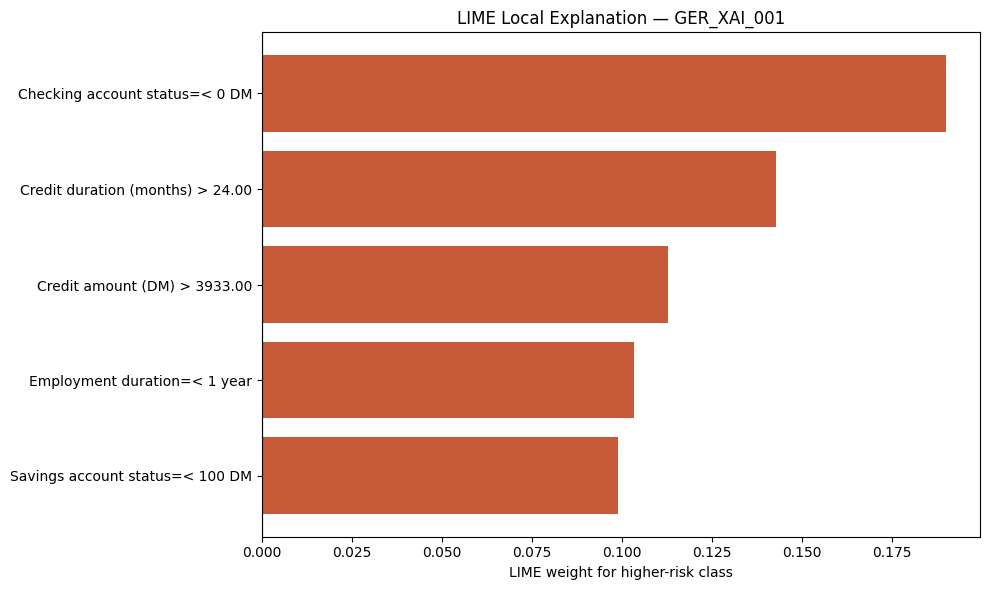

In [9]:
representative_case_id = "GER_XAI_001"
representative_factors = lime_local.loc[
    lime_local["case_id"].eq(representative_case_id)
].sort_values("rank", ascending=False)
colors = ["#C75B39" if weight > 0 else "#315E8A" for weight in representative_factors["lime_weight"]]
plt.figure(figsize=(10, 6))
plt.barh(representative_factors["display_rule"], representative_factors["lime_weight"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("LIME weight for higher-risk class")
plt.title(f"LIME Local Explanation — {representative_case_id}")
plt.tight_layout()
REPRESENTATIVE_PLOT_PATH = PLOTS_DIR / "german_credit_lime_representative_explanation.png"
plt.savefig(REPRESENTATIVE_PLOT_PATH, dpi=180, bbox_inches="tight")
plt.show()


## 9. Sparsity and compactness


In [10]:
sparsity_rows = []
for case_id, group in lime_local.groupby("case_id", sort=False):
    absolute_weights = group.sort_values("rank")["lime_weight"].abs().to_numpy()
    total = absolute_weights.sum()
    ordered = np.sort(absolute_weights)[::-1]
    cumulative = np.cumsum(ordered) / total if total > 0 else np.zeros_like(ordered)
    sparsity_rows.append({
        "case_id": case_id,
        "number_of_reported_features": len(group),
        "absolute_weight_sum": total,
        "features_for_50_percent": int(np.searchsorted(cumulative, 0.50) + 1) if total > 0 else 0,
        "features_for_80_percent": int(np.searchsorted(cumulative, 0.80) + 1) if total > 0 else 0,
    })
lime_sparsity = pd.DataFrame(sparsity_rows)
LIME_SPARSITY_PATH = ARTIFACTS_DIR / "lime_sparsity_metrics.csv"
lime_sparsity.to_csv(LIME_SPARSITY_PATH, index=False)
display(lime_sparsity.describe().loc[["mean", "50%", "min", "max"]])


,number_of_reported_features,absolute_weight_sum,features_for_50_percent,features_for_80_percent
mean,5.0,0.641713,2.25,4.0
50%,5.0,0.628168,2.00,4.0
min,5.0,0.526627,2.00,4.0
max,5.0,0.769555,3.00,4.0


## 10. Same-seed reproducibility

The first five cases are explained twice using fresh explainers with identical settings. This tests same-seed reproduction, not stability across seeds.


In [11]:
stability_rows = []
for case_number, case in enumerate(xai_cases.head(5).itertuples(index=False)):
    instance = X_test_lime.iloc[case_positions[case_number]].to_numpy()
    _, first_records = generate_explanation(instance)
    _, second_records = generate_explanation(instance)
    first_features = [selected_features[row["feature_index"]] for row in first_records]
    second_features = [selected_features[row["feature_index"]] for row in second_records]
    first_weights = np.array([row["lime_weight"] for row in first_records])
    second_weights = np.array([row["lime_weight"] for row in second_records])
    maximum_difference = float(np.max(np.abs(first_weights - second_weights)))
    same_features = set(first_features) == set(second_features)
    same_order = first_features == second_features
    exact_reproduction = same_order and maximum_difference <= 1e-12
    stability_rows.append({
        "case_id": case.case_id,
        "diagnostic": "same-seed reproducibility / preliminary stability diagnostic",
        "same_top_5_features": same_features,
        "same_feature_order": same_order,
        "maximum_absolute_weight_difference": maximum_difference,
        "exact_reproduction": exact_reproduction,
    })
lime_stability = pd.DataFrame(stability_rows)
LIME_STABILITY_PATH = ARTIFACTS_DIR / "lime_preliminary_stability.csv"
lime_stability.to_csv(LIME_STABILITY_PATH, index=False)
display(lime_stability)


,case_id,diagnostic,same_top_5_features,same_feature_order,maximum_absolute_weight_difference,exact_reproduction
0,GER_XAI_001,same-seed reproducibility / preliminary stabil...,True,True,0.0,True
1,GER_XAI_002,same-seed reproducibility / preliminary stabil...,True,True,0.0,True
2,GER_XAI_003,same-seed reproducibility / preliminary stabil...,True,True,0.0,True
3,GER_XAI_004,same-seed reproducibility / preliminary stabil...,True,True,0.0,True
4,GER_XAI_005,same-seed reproducibility / preliminary stabil...,True,True,0.0,True


## 11. Preliminary faithfulness

The highest-ranked feature with a valid training-derived replacement is changed. This measures frozen-model sensitivity rather than causality.


In [12]:
training_medians = X_train_raw[numeric_features].median()
training_category_counts = {feature: X_train_raw[feature].value_counts() for feature in categorical_features}
faithfulness_rows = []
for case in xai_cases.head(5).itertuples(index=False):
    factors = lime_local.loc[lime_local["case_id"].eq(case.case_id)].sort_values("rank")
    top_lime_feature = factors.iloc[0]["original_feature"]
    original_row = X_test_raw.loc[[case.row_index], selected_features].copy()
    intervened_feature = None
    replacement = None
    for factor in factors.itertuples(index=False):
        feature = factor.original_feature
        original_value = original_row.iloc[0][feature]
        if feature in numeric_features:
            candidate_value = float(training_medians[feature])
            if not np.isclose(float(original_value), candidate_value):
                intervened_feature, replacement = feature, candidate_value
                break
        else:
            for candidate_value in training_category_counts[feature].index:
                if candidate_value != original_value:
                    intervened_feature, replacement = feature, candidate_value
                    break
            if intervened_feature is not None:
                break
    assert intervened_feature is not None
    original_value = original_row.iloc[0][intervened_feature]
    intervened_row = original_row.copy()
    intervened_row.loc[case.row_index, intervened_feature] = replacement
    intervened_processed = preprocessor.transform(intervened_row[selected_features])
    intervened_probability = float(model.predict_proba(intervened_processed)[0, 1])
    changed = bool(original_value != replacement)
    assert changed
    faithfulness_rows.append({
        "case_id": case.case_id,
        "top_lime_feature": top_lime_feature,
        "intervened_feature": intervened_feature,
        "original_feature_value": display_value(intervened_feature, original_value),
        "replacement_value": display_value(intervened_feature, replacement),
        "feature_actually_changed": changed,
        "faithfulness_test_status": "completed",
        "original_probability": float(case.predicted_probability),
        "intervened_probability": intervened_probability,
        "absolute_score_change": abs(intervened_probability - float(case.predicted_probability)),
    })
lime_faithfulness = pd.DataFrame(faithfulness_rows)
LIME_FAITHFULNESS_PATH = ARTIFACTS_DIR / "lime_preliminary_faithfulness.csv"
lime_faithfulness.to_csv(LIME_FAITHFULNESS_PATH, index=False)
display(lime_faithfulness)


,case_id,top_lime_feature,intervened_feature,original_feature_value,replacement_value,feature_actually_changed,faithfulness_test_status,original_probability,intervened_probability,absolute_score_change
0,GER_XAI_001,Attribute1,Attribute1,< 0 DM,No checking account,True,completed,0.946682,0.812929,0.133753
1,GER_XAI_002,Attribute1,Attribute1,< 0 DM,No checking account,True,completed,0.925695,0.649313,0.276381
2,GER_XAI_003,Attribute1,Attribute1,< 0 DM,No checking account,True,completed,0.906782,0.278392,0.628390
3,GER_XAI_004,Attribute1,Attribute1,< 0 DM,No checking account,True,completed,0.906360,0.423360,0.482999
4,GER_XAI_005,Attribute2,Attribute2,36,18,True,completed,0.905507,0.851712,0.053795


## 12. Local surrogate fidelity


In [13]:
lime_fidelity = lime_local.groupby("case_id", sort=False).first().reset_index()[[
    "case_id", "row_index", "predicted_probability",
    "lime_local_prediction", "local_fidelity_r2",
]]
lime_fidelity["absolute_local_prediction_error"] = (
    lime_fidelity["predicted_probability"] - lime_fidelity["lime_local_prediction"]
).abs()
LIME_FIDELITY_PATH = ARTIFACTS_DIR / "lime_local_fidelity.csv"
lime_fidelity.to_csv(LIME_FIDELITY_PATH, index=False)
display(lime_fidelity)
display(lime_fidelity[["local_fidelity_r2", "absolute_local_prediction_error"]].describe().loc[["mean", "50%", "min", "max"]])


,case_id,row_index,predicted_probability,lime_local_prediction,local_fidelity_r2,absolute_local_prediction_error
0,GER_XAI_001,11,0.946682,0.836608,0.282474,0.110074
1,GER_XAI_002,832,0.925695,0.732164,0.278182,0.193531
2,GER_XAI_003,998,0.906782,0.687279,0.260511,0.219504
3,GER_XAI_004,831,0.906360,0.661807,0.227846,0.244553
4,GER_XAI_005,141,0.905507,0.781831,0.207366,0.123676
5,GER_XAI_006,273,0.501852,0.468598,0.192067,0.033253
6,GER_XAI_007,653,0.503441,0.683324,0.174939,0.179883
7,GER_XAI_008,944,0.513555,0.658334,0.225075,0.144779
8,GER_XAI_009,992,0.515243,0.380281,0.205977,0.134962
9,GER_XAI_010,677,0.517682,0.668718,0.182711,0.151036


,local_fidelity_r2,absolute_local_prediction_error
mean,0.319525,0.144864
50%,0.280328,0.117771
min,0.174939,0.011321
max,0.518558,0.475035


## 13. Metadata and quality checks


In [14]:
LIME_METADATA_PATH = ARTIFACTS_DIR / "lime_metadata.json"
lime_metadata = {
    "dataset": "UCI Statlog German Credit Data (ID 144)",
    "model_path": str(required_paths["model"].relative_to(BACKEND_DIR)),
    "preprocessor_path": str(required_paths["preprocessor"].relative_to(BACKEND_DIR)),
    "training_background_rows": len(X_train_lime),
    "fixed_xai_case_count": len(xai_cases),
    "original_feature_count": len(selected_features),
    "num_samples": NUM_SAMPLES,
    "num_features": NUM_FEATURES,
    "random_state": RANDOM_STATE,
    "wrapper_maximum_probability_difference": wrapper_max_difference,
    "representative_case": representative_case_id,
    "stability_cases_tested": len(lime_stability),
    "faithfulness_cases_tested": len(lime_faithfulness),
    "categorical_codes_derived_from": "frozen training partition only",
    "model_retrained": False,
    "preprocessor_refitted": False,
}
LIME_METADATA_PATH.write_text(json.dumps(lime_metadata, indent=2), encoding="utf-8")

assert hasattr(model, "classes_")
assert len(X_train_raw) == 800 and len(X_test_raw) == 200
assert max(metric_differences.values()) <= 1e-12
assert wrapper_max_difference <= 1e-12
assert len(xai_cases) == 20
assert len(lime_local) == 100
assert len(pd.read_csv(LIME_TOP_PATH)) == 100
assert len(lime_plain) == 20
assert len(lime_sparsity) == 20
assert len(lime_stability) == 5
assert len(lime_faithfulness) == 5
assert len(lime_fidelity) == 20

print("Frozen model loaded: True")
print("Exact train rows reconstructed: 800")
print("Exact test rows reconstructed: 200")
print("Frozen predictions reproduced: True")
print(f"LIME wrapper probability difference: {wrapper_max_difference:.12g}")
print("Fixed XAI cases: 20")
print("Local explanation rows: 100")
print("Top-factor rows: 100")
print("Plain-English rows: 20")
print("Sparsity rows: 20")
print("Stability rows: 5")
print("Faithfulness rows: 5")
print("Local-fidelity rows: 20")
print("Model retrained: False")
print("Preprocessor refitted: False")
print("New split created: False")
print("SHAP rerun: False")
print("DiCE executed: False")
print("Dataset 1 modified: False")


Frozen model loaded: True
Exact train rows reconstructed: 800
Exact test rows reconstructed: 200
Frozen predictions reproduced: True
LIME wrapper probability difference: 0
Fixed XAI cases: 20
Local explanation rows: 100
Top-factor rows: 100
Plain-English rows: 20
Sparsity rows: 20
Stability rows: 5
Faithfulness rows: 5
Local-fidelity rows: 20
Model retrained: False
Preprocessor refitted: False
New split created: False
SHAP rerun: False
DiCE executed: False
Dataset 1 modified: False
